In [89]:
import random
import numpy as np
import matplotlib.pyplot as plt
# Items A–E
items = ['A','B','C','D','E']

# Values of items
values = [50, 30, 20, 30, 50]

# Weights of items
weights = [30, 50, 40,20, 60]

# Maximum capacity of knapsack
capacity = 110

num_items = len(items)

population_size = 6
generations = 30
mutation_rate = 0.1

In [90]:
def create_population():

    population = []

    for _ in range(population_size):
        chromosome = [random.randint(0,1) for _ in range(num_items)]
        population.append(chromosome)

    return population


In [91]:
def fitness(chromosome):

    total_value = 0
    total_weight = 0

    for i in range(num_items):

        if chromosome[i] == 1:
            total_value += values[i]
            total_weight += weights[i]

    if total_weight > capacity:
        return 0

    return total_value

In [92]:
def selection(population):

    fitness_values = [fitness(ch) for ch in population]
    total_fitness = sum(fitness_values)

    if total_fitness == 0:
        return random.choice(population)

    probabilities = [f/total_fitness for f in fitness_values]

    selected = random.choices(population, probabilities)[0]

    return selected

In [93]:
def crossover(parent1, parent2):

    point = random.randint(1, num_items-1)

    child = parent1[:point] + parent2[point:]

    return child

In [94]:
def mutation(chromosome):

    for i in range(num_items):

        if random.random() < mutation_rate:
            chromosome[i] = 1 - chromosome[i]

    return chromosome

In [95]:
population = create_population()

best_fitness_history = []

for generation in range(generations):

    new_population = []

    for _ in range(population_size):

        parent1 = selection(population)
        parent2 = selection(population)

        child = crossover(parent1, parent2)

        child = mutation(child)

        new_population.append(child)

    population = new_population

    best = max(population, key=fitness)
    best_fitness_history.append(fitness(best))

best_solution = max(population, key=fitness)

In [96]:
population

[[1, 1, 0, 0, 1],
 [1, 1, 0, 0, 0],
 [1, 0, 0, 1, 1],
 [1, 1, 0, 0, 0],
 [0, 1, 0, 0, 0],
 [1, 1, 0, 0, 0]]

In [97]:
best_solution

[1, 0, 0, 1, 1]

In [98]:
print("Best Chromosome:", best_solution)

selected_items = [items[i] for i in range(num_items) if best_solution[i] == 1]

print("Selected Items:", selected_items)
print("Best Fitness (Total Value):", fitness(best_solution))

total_weight = sum(weights[i] for i in range(num_items) if best_solution[i]==1)

print("Total Weight:", total_weight)


Best Chromosome: [1, 0, 0, 1, 1]
Selected Items: ['A', 'D', 'E']
Best Fitness (Total Value): 130
Total Weight: 110


Chart 1 — Fitness Improvement (Finding Optimum Solution)
This chart shows how the GA converges toward the optimal solution.

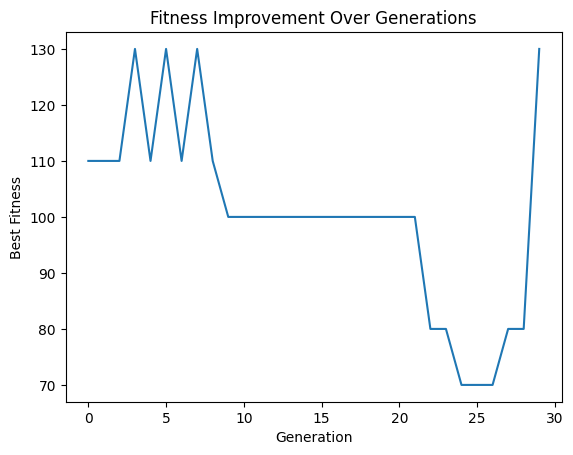

In [99]:

plt.figure()

plt.plot(best_fitness_history)

plt.title("Fitness Improvement Over Generations")

plt.xlabel("Generation")

plt.ylabel("Best Fitness")

plt.show()

# Chart 2 — Final Selected Items

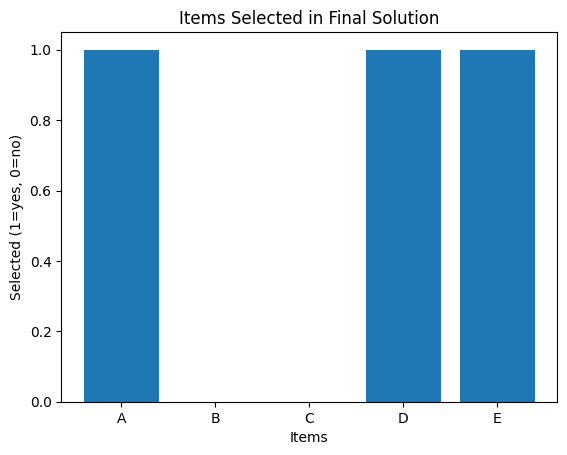

In [100]:
selected = [best_solution[i] for i in range(num_items)]

plt.figure()

plt.bar(items, selected)

plt.title("Items Selected in Final Solution")

plt.xlabel("Items")

plt.ylabel("Selected (1=yes, 0=no)")

plt.show()